##Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM,SimpleRNN, GRU, Bidirectional, Dropout

from sklearn.utils import class_weight

##Load dataset
https://huggingface.co/datasets/dair-ai/emotion

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
label_names= emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train=pd.DataFrame({'text':train_text,
                       'label':[label_name[i] for i in train_label]})
#df_train.head()

df_test=pd.DataFrame({'text':test_text,
                      'label':[label_name[i] for i in test_label]})
#df_test.head()

##Exploratory Data Analysis(EDA)

<Axes: xlabel='label', ylabel='count'>

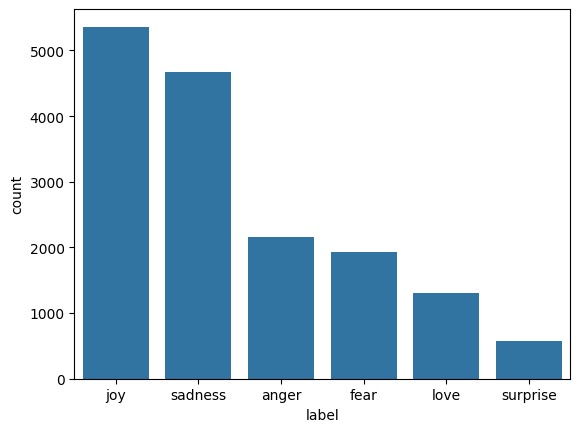

In [ ]:
sns.countplot(x='label',data=df_train, order = df_train['label'].value_counts().index)

##Data Preprocessing Using NLP

In [ ]:
from IPython.core.magic import on_off
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
padded_train_sequence = pad_sequences(train_sequence, maxlen = 50,padding='post', truncating = 'post')

test_sequence = tokenizer.texts_to_sequences(df_test['text'])
padded_test_sequence = pad_sequences(test_sequence, maxlen = 50,padding='post', truncating = 'post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes

6

##Shared Training Utilities

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

##Plain Foundational Models

#Simple RNN Model

In [ ]:
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #output layer
])


rnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.fit(padded_train_sequence,
          train_labels,
          validation_data=(padded_test_sequence, test_labels),
          epochs= 20,
          batch_size= 32,
          class_weight=class_weight_dict,
          callbacks = [early_stopping]
          )
rnn_model_loss, rnn_model_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f'Test Loss: {rnn_model_loss}')
print(f'Test Accuracy: {rnn_model_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.1594 - loss: 1.8129 - val_accuracy: 0.0830 - val_loss: 1.8061
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.1437 - loss: 1.7929 - val_accuracy: 0.1115 - val_loss: 1.8006
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.1478 - loss: 1.7741 - val_accuracy: 0.1320 - val_loss: 1.7841
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0830 - loss: 1.8061
Test Loss: 1.8060539960861206
Test Accuracy: 0.08299999684095383


LSTM Model

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#lstm_model.summary()

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 119ms/step - accuracy: 0.1554 - loss: 1.7957 - val_accuracy: 0.0810 - val_loss: 1.8056
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - accuracy: 0.1583 - loss: 1.7938 - val_accuracy: 0.0810 - val_loss: 1.8097
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.1656 - loss: 1.7927 - val_accuracy: 0.3430 - val_loss: 1.7745
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.2246 - loss: 1.7349 - val_accuracy: 0.2130 - val_loss: 1.7497
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 112ms/step - accuracy: 0.3574 - loss: 1.4569 - val_accuracy: 0.5075 - val_loss: 1.2969
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.5234 - loss: 1.0960 - val_accuracy: 0.6650 - val_loss: 0.8750
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.6818 - loss: 0.8652 - val_accuracy: 0.7770 - val_loss: 0.6692
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.8107 - loss: 0

Standard GRU Model

In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#lstm_model.summary()

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {gru_loss}")
print(f"LSTM Accuracy: {gru_accuracy}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 103ms/step - accuracy: 0.1523 - loss: 1.7965 - val_accuracy: 0.0795 - val_loss: 1.8131
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.1593 - loss: 1.7945 - val_accuracy: 0.1375 - val_loss: 1.7852
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.1535 - loss: 1.7940 - val_accuracy: 0.1145 - val_loss: 1.7817
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8835 - loss: 0.4100
LSTM Loss: 0.4100281894207001
LSTM Accuracy: 0.8834999799728394


In [ ]:
result_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_model_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_model_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Accuracy', ascending=False)

result_df

,Model,Loss,Accuracy
1,LSTM,0.410028,0.8835
2,GRU,0.410028,0.8835
0,Simple RNN,1.806054,0.0830


##Advanced Model

In [ ]:
BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 10,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 280ms/step - accuracy: 0.7233 - loss: 0.7664 - val_accuracy: 0.8935 - val_loss: 0.2992
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 275ms/step - accuracy: 0.9299 - loss: 0.1918 - val_accuracy: 0.9185 - val_loss: 0.2335
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 270ms/step - accuracy: 0.9524 - loss: 0.1275 - val_accuracy: 0.9170 - val_loss: 0.2489
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 270ms/step - accuracy: 0.9651 - loss: 0.0987 - val_accuracy: 0.9180 - val_loss: 0.2228
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 269ms/step - accuracy: 0.9746 - loss: 0.0677 - val_accuracy: 0.9255 - val_loss: 0.2443
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 273ms/step - accuracy: 0.9746 - loss: 0.0774 - val_accuracy: 0.9250 - val_loss: 0.2325
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9802 - loss: 0.0583 - val_accuracy: 0.9200 - val_loss: 0.2911


##Overall Result and Bias Anaysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step


<Axes: >

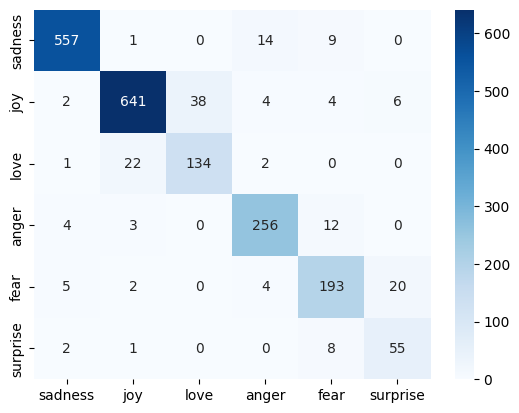

In [ ]:

from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

##Final Prediction

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


##Save Tokenzier and Model

In [ ]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)